# Convolutional Neural Network: 
## Food Recognition

In [397]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

from copy import deepcopy

# Progress bar
from tqdm.auto import tqdm
from datetime import datetime
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms

from sklearn.model_selection import train_test_split

import tensorboard as tb
from torch.utils.tensorboard import SummaryWriter

In [398]:
%reload_ext tensorboard

## CNN Structure:

In [ ]:
import torch.nn.init as init

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        init.kaiming_normal_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)

    if isinstance(m, nn.Linear):
        init.kaiming_normal_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)


class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
        # block 1
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.GELU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.GELU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.05),

        # block 2
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.GELU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.GELU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.10),

        # block 3
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.GELU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.GELU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.15),

        # block 4
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.GELU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.GELU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.20),

        # block 5
        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.GELU(),
        nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 80)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    @property
    def device(self):
        """
        Returns the device on which the model is. Can be useful in some situations.
        """
        return next(self.parameters()).device

### Seed

In [400]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): # GPU operation have separate seed
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


### Evaluation

In [401]:
def eval_model(model, data_loader, loss_module, device):
    model.eval()

    total_correct = 0
    total_samples = 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, dtype=torch.float32)
            targets = targets.to(device)

            outputs = model(inputs)

            loss = loss_module(outputs, targets)
            running_loss += loss.item() * inputs.size(0)

            preds = outputs.argmax(dim=1)

            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)

    val_loss = running_loss / total_samples
    val_acc = total_correct / total_samples

    return val_loss, val_acc

### Identifying feature maps

In [402]:
def log_feature_maps(model, images, writer, epoch, device):
    model.eval()

    images = images.to(device)

    # pak eerste conv layer
    conv_layer = model.features[0]

    # forward hook (vangt activaties)
    activations = {}

    def hook_fn(module, input, output):
        activations["features"] = output.detach()

    handle = conv_layer.register_forward_hook(hook_fn)

    # forward pass
    model(images)

    handle.remove()

    # shape: (batch, channels, H, W)
    feature_maps = activations["features"]

    # pak eerste image uit batch
    fmap = feature_maps[0]

    # maak grid van eerste 16 filters
    grid = torchvision.utils.make_grid(
        fmap[:16].unsqueeze(1),
        normalize=True,
        scale_each=True,
        nrow=4
    )

    writer.add_image("FeatureMaps/conv1", grid, epoch)

### Analyze Data

Train total items: 30612
Test total items: 7653
Train images: 30612
Test images: 7653


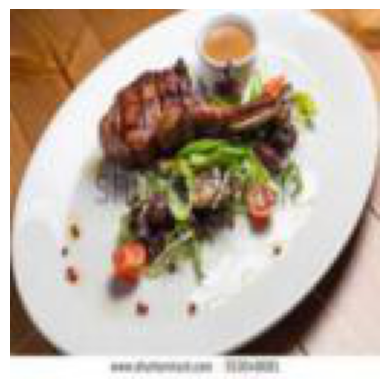

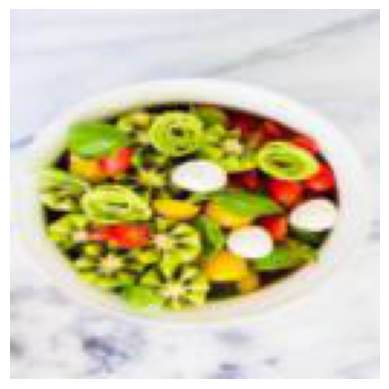

In [403]:
# Creating paths
ROOT = Path("food-recognition-challenge-2026")

TRAIN_DIR = ROOT / "train_set_128"           # Already transformed training set to 64x64
TEST_DIR  = ROOT / "test_set"
TRAIN_CSV = ROOT / "train_labels.csv"
CLASS_TXT = ROOT / "class_list_food.txt"

# Unpacking the lists of images
train_files = list(TRAIN_DIR.rglob("*.jpg"))
test_files  = list(TEST_DIR.rglob("*"))

# Unpacking the images out of the list
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
train_imgs = [p for p in TRAIN_DIR.rglob("*") if p.suffix.lower() in img_exts]
test_imgs  = [p for p in TEST_DIR.rglob("*") if p.suffix.lower() in img_exts]

# Amount of images
print("Train total items:", len(train_files))
print("Test total items:", len(test_files))
print("Train images:", len(train_imgs))
print("Test images:", len(test_imgs))

# Showing images
for i in range(2):
    image = Image.open(train_files[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [404]:
# Head of train_labels csv
df = pd.read_csv(TRAIN_CSV)
print(df.head())


      img_name  label
0  train_1.jpg     21
1  train_2.jpg     29
2  train_3.jpg     17
3  train_4.jpg     21
4  train_5.jpg     50


In [405]:
# Creating classes from class_list_food.txt
classes = dict()

with open(CLASS_TXT, 'r') as c:
    for i in c:
        i = i.strip()
        if not i:
            continue

        k, v = i.split(' ', 1)
        classes[k] = v

# Amount of classes
print(len(classes))

80


In [406]:
sizes = []

for p in train_imgs:
    with Image.open(p) as im:
        sizes.append(im.size)         # (width, height)

print("Example sizes:", sizes[:10])

ws = [w for (w,h) in sizes]
hs = [h for (w,h) in sizes]
print("Width min/max:", min(ws), max(ws))
print("Height min/max:", min(hs), max(hs))


Example sizes: [(128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128)]
Width min/max: 128 128
Height min/max: 128 128


In [407]:
train_label, val_label = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(len(train_label), len(val_label))

24489 6123


In [408]:
"""transform = transforms.Resize((224,224))
OUTPUT_DIR = 'train_set_224'
for img_path in TRAIN_DIR.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

        # open image
        img = Image.open(img_path).convert("RGB")

        # resize
        img = transform(img)

        # nieuwe path maken
        new_path = OUTPUT_DIR / img_path.relative_to(TRAIN_DIR)
        new_path.parent.mkdir(parents=True, exist_ok=True)

        # opslaan
        img.save(new_path)"""

'transform = transforms.Resize((224,224))\nOUTPUT_DIR = \'train_set_224\'\nfor img_path in TRAIN_DIR.rglob("*"):\n    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:\n\n        # open image\n        img = Image.open(img_path).convert("RGB")\n\n        # resize\n        img = transform(img)\n\n        # nieuwe path maken\n        new_path = OUTPUT_DIR / img_path.relative_to(TRAIN_DIR)\n        new_path.parent.mkdir(parents=True, exist_ok=True)\n\n        # opslaan\n        img.save(new_path)'

### Creating Datasets

In [409]:
class FoodDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]["img_name"]
        label = self.img_labels.iloc[idx]["label"] - 1

        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [410]:
IMG_SIZE = 128 # Already pre processed
BATCH_SIZE = 64

train_df = train_label.to_csv("food-recognition-challenge-2026/train_split.csv", index=False)
val_df = val_label.to_csv("food-recognition-challenge-2026/val_split.csv", index=False)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3), # forces system to use other feature maps
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

])

validation_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = FoodDataset("food-recognition-challenge-2026/train_split.csv", TRAIN_DIR, transform=train_transform)
validation_dataset = FoodDataset("food-recognition-challenge-2026/val_split.csv", TRAIN_DIR, transform=validation_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

## Training

In [411]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    seed,
    device,
    optimizer,
    loss_module,
    scheduler,
    patience,
    start_epoch,
):
    # Set seed for reproducibility
    set_seed(seed)

    # TensorBoard writer & Logging
    writer = SummaryWriter()
    logging_dict = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "best_epoch": [],
        "best_accuracy": []
    }

    # Initialize best model tracking
    best_val_acc = -1.0
    best_epoch = -1
    best_model = deepcopy(model)
    best_optimizer_state = deepcopy(optimizer.state_dict())
    epochs_without_improvement = 0

    # Scheduler for reducing lr on reaching plateau
    scheduler = scheduler

    # Start training over epochs
    for epoch in tqdm(range(start_epoch, epochs), desc="Epochs"):
        model.train()

        running_loss = 0.0
        total_correct = 0
        total_samples = 0

        # Iterate over training batches
        for inputs, targets in tqdm(train_loader, desc="Training", leave=False):
            # Move batch to device
            inputs = inputs.to(device, dtype=torch.float32)
            targets = targets.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(inputs)
            loss = loss_module(logits, targets)

            # Backward pass and parameter update
            loss.backward()

            total_norm = 0

            # Calculating Gradient norm
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2

            total_norm = total_norm ** 0.5

            writer.add_scalar("Gradients/grad_norm", total_norm, epoch)

            optimizer.step()

            # Update training statistics
            running_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)

        # Compute epoch metrics
        epoch_loss = running_loss / total_samples
        epoch_acc = total_correct / total_samples

        # Evaluate on validation / test set
        val_loss, val_acc = eval_model(model, val_loader, loss_module, device)

        # Write training metrics to TensorBoard
        writer.add_scalars(
            "Accuracy",
            {
                "train": epoch_acc,
                "val": val_acc
            },
            epoch
        )

        writer.add_scalars(
            "Loss",
            {
                "train": epoch_loss,
                "val": val_loss
            },
            epoch
    )
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

        for name, param in model.named_parameters():
            writer.add_histogram(f"Weights/{name}", param, epoch)

        gap = epoch_acc - val_acc
        writer.add_scalar("Generalization/gap", gap, epoch)

        # Feature map imaging
        example_images, _ = next(iter(val_loader))

        log_feature_maps(
            model,
            example_images,
            writer,
            epoch,
            device
        )

        # Send scheduler the accuracy
        scheduler.step(val_acc)

        # Print progress
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={epoch_loss:.4f} | "
            f"train_acc={epoch_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        # Saving in dict
        logging_dict["epoch"].append(epoch)
        logging_dict["train_loss"].append(epoch_loss)
        logging_dict["train_accuracy"].append(epoch_acc)
        logging_dict["val_loss"].append(val_loss)
        logging_dict["val_accuracy"].append(val_acc)

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            logging_dict["best_epoch"] = best_epoch
            best_model = deepcopy(model)
            best_optimizer_state = deepcopy(optimizer.state_dict())
            epochs_without_improvement = 0
            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": best_model.state_dict(),
                    "optimizer_state_dict": best_optimizer_state,
                    "val_acc": best_val_acc
                },
                "best_model.pth")
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement} epoch(s)")

        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")

            timestamp = datetime.now().strftime("%Y_%m_%d_%H:%M")
            filename = f"model_{timestamp}_acc={best_val_acc*100:.2f}.pth"
            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": best_model.state_dict(),
                    "optimizer_state_dict": best_optimizer_state,
                    "val_acc": best_val_acc
                },
                f"models/{filename}")

            print(f"Saved model: {filename}")
            writer.close()
            break

    # Evaluate the best model final time
    best_val_loss, best_test_acc = eval_model(best_model, val_loader, loss_module, device)

    print(f"Best epoch: {best_epoch + 1}")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Best test accuracy: {best_test_acc:.4f}")

    logging_dict["best_accuracy"].append(best_test_acc)

    # Close TensorBoard writer
    writer.close()

    # Save best model weights with date and time
    timestamp = datetime.now().strftime("%Y_%m_%d_%H:%M")
    filename = f"model_{timestamp}_acc={best_val_acc*100:.2f}.pth"

    torch.save(
        {"epoch": best_epoch,
        "model_state_dict": best_model.state_dict(),
        "optimizer_state_dict": best_optimizer_state,
        "val_acc": best_val_acc
        },
        f"models/{filename}"
    )

    print(f"Saved model: {filename}")

    return best_model, logging_dict

In [412]:
model = CNN().to(device)
model.apply(init_weights)

epochs = 100
lr = 0.001
weight_decay=0.001
momentum = 0 # for adam 0 is standard
loss_module = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
patience = 15 # Early stopping
start_epoch = 0

best_model, logging_dict = train_model(model=model,
            train_loader=train_loader,
            val_loader=validation_loader,
            device=device,
            epochs=epochs,
            seed=42,
            loss_module=loss_module,
            optimizer=optimizer,
            scheduler=scheduler,
            patience=patience,
            start_epoch=start_epoch)

best_idx = logging_dict["val_accuracy"].index(max(logging_dict["val_accuracy"]))

# logging the runs and noting differences in the experiment
data = {'model': 'CNN_10_test2',
        'Training accuracy': round(logging_dict["train_accuracy"][best_idx], 4),
        'Best validation accuracy': round(max(logging_dict["val_accuracy"]), 4),
        'Best epoch': logging_dict['best_epoch'],
        'Total epochs': epochs,
        'Image size': IMG_SIZE,
        'Batch size': BATCH_SIZE,
        'Activation function': 'GELU',
        'Loss function': 'CrossEntropy',
        'Optimizer': 'AdamW',
        'Learning rate': lr,
        'Weight decay': weight_decay,
        'Momentum': momentum,
        'Padding': 1,
        'Scheduler': 'Yes on plateau, patience=5',
        'Dropout': '0.05, 0.10, 0.15, 0.2, 0.3',
        'transforms': 'RandomHorizontalFlip, Normalizer:ImageNet, RandomRotation(10), RandomErasing(p=0.3)',
        'Description' : '4 blocks of: conv-bn-actf,conv-bn-actf-maxp-drp. Removed 1 max pooling. Ending with adaptive pooling before cf',
        'All validation accuracy': str(logging_dict['val_accuracy']),
        'All training accuracy': str(logging_dict['train_accuracy'])
        }

df = pd.DataFrame([data])
df.to_csv("logging.csv", mode="a", index=False, header=not os.path.exists("logging.csv"), sep=";", decimal=",")

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/383 [00:00<?, ?it/s]

Epoch 1/100 | loss=4.0369 | train_acc=0.0680 | val_loss=3.6900 | val_acc=0.1184


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Epoch 2/100 | loss=3.7546 | train_acc=0.1048 | val_loss=3.5224 | val_acc=0.1405


...

Epoch 98/100 | loss=1.2682 | train_acc=0.6412 | val_loss=2.1182 | val_acc=0.5020
No improvement for 12 epoch(s)


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Epoch 99/100 | loss=1.2665 | train_acc=0.6419 | val_loss=2.1163 | val_acc=0.5051
No improvement for 13 epoch(s)


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Epoch 100/100 | loss=1.2611 | train_acc=0.6427 | val_loss=2.1154 | val_acc=0.5035
No improvement for 14 epoch(s)
Best epoch: 86
Best validation loss: 2.1106
Best test accuracy: 0.5074
Saved model: model_2026_03_14_10:19_acc=50.74.pth


In [416]:
# %rm -r runs
%tensorboard --logdir runs

Reusing TensorBoard on port 6007 (pid 98437), started 9:36:56 ago. (Use '!kill 98437' to kill it.)

### Second cycle of training

In [414]:
def second_train_model(model):
    return model

In [415]:
returning_model = CNN()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# checkpoint = torch.load("models/model_2026_03_14_02:29_acc=33.92.pth")
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
returning_model.load_state_dict(checkpoint["model_state_dict"])
returning_model.to(device)

patience = 15 # Early stopping
start_epoch = checkpoint['epochs']
epochs = 50

best_model, logging_dict = train_model(model=model,
            train_loader=train_loader,
            val_loader=validation_loader,
            device=device,
            epochs=epochs,
            seed=42,
            loss_module=nn.CrossEntropyLoss(),
            optimizer=optimizer)

best_idx = logging_dict["val_accuracy"].index(max(logging_dict["val_accuracy"]))

# logging the runs and noting differences in the experiment
data = {'model': 'CNN_6.1',
        'Training accuracy': round(logging_dict["train_accuracy"][best_idx], 4),
        'Best validation accuracy': round(max(logging_dict["val_accuracy"]), 4),
        'Best epoch': logging_dict['best_epoch'],
        'Total epochs': epochs,
        'Image size': IMG_SIZE,
        'Batch size': BATCH_SIZE,
        'Activation function': 'GELU',
        'Loss function': 'CrossEntropy',
        'Optimizer': 'AdamW',
        'Learning rate': lr,
        'Weight decay': weight_decay,
        'Momentum': momentum,
        'Padding': 1,
        'Scheduler': 'Yes on plateau, patience=5',
        'Dropout': '0.05, 0.10, 0.15, 0.2, 0.3',
        'transforms': 'RandomHorizontalFlip, Normalizer:ImageNet',
        'Description' : '4 blocks of: conv-bn-actf,conv-bn-actf-maxp-drp. Removed 1 max pooling. Ending with adaptive pooling before cf',
        'All validation accuracy': str(logging_dict['val_accuracy']),
        'All training accuracy': str(logging_dict['train_accuracy'])
        }

df = pd.DataFrame([data])
df.to_csv("logging.csv", mode="a", index=False, header=not os.path.exists("logging.csv"), sep=";", decimal=",")

KeyError: 'epochs'

In [ ]:
% tensorboard --logdir runs

## Testing phase

In [417]:
def predict_test_set(model, test_loader, output_csv="submissionSGD.csv"):
    model.eval()

    all_names = []
    all_preds = []

    with torch.no_grad():
        for inputs, names in test_loader:
            inputs = inputs.to(model.device, dtype=torch.float32)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().tolist()

            all_names.extend(names)
            all_preds.extend([p + 1 for p in preds])

    submission_df = pd.DataFrame({
        "img_name": all_names,
        "label": all_preds
    })

    submission_df.to_csv(output_csv, index=False)
    return submission_df

In [418]:
class FoodTestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.transform = transform

        self.image_paths = sorted(
            [p for p in self.img_dir.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}],
            key=lambda p: int(p.stem.split("_")[1])
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path.name

In [419]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = FoodTestDataset(TEST_DIR, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [427]:
model = CNN().to(device)
checkpoint = torch.load(
    "models/model_2026_03_14_10:19_acc=50.74.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

submission_df = predict_test_set(model, test_loader, output_csv="submissionSGD.csv")
print(submission_df.head())

/var/folders/_z/v7hhbm291y76vlkstpjxff6h0000gn/T/ipykernel_87897/1598255251.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


     img_name  label
0  test_1.jpg     19
1  test_2.jpg     60
2  test_3.jpg      9
3  test_4.jpg     45
4  test_5.jpg      2


In [ ]:
%tensorboard --logdir runs/FRC-Challenge

Reusing TensorBoard on port 6006 (pid 48575), started 21:32:15 ago. (Use '!kill 48575' to kill it.)